In [1]:
import os
import re
import ast
import json
import random
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt

from util import *


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### initiate vars

In [4]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

all_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [5]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1',
#               'male_dem_ny_1',
#               'male_rep_ny_1',
#               'female_dem_ny_1',
#               'female_rep_ny_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### pick comment for manual annotation

In [19]:
random.seed(36)
rand_indices = random.sample(range(merged_df.shape[0]), 50)

In [20]:
merged_df = merged_df[merged_df['Main Topic'] == 'Political']
merged_df.shape

(827, 16)

In [21]:
merged_df.iloc[rand_indices][['account', 'urlid', 'caption', 'chronological_comment']].to_clipboard()

### processing and labels 

In [6]:
news_df = pd.read_csv('/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews_comments.csv')
news_df.shape

(1367, 13)

In [7]:
news_df.dropna(subset=['caption'], inplace=True)
news_df.shape

(1100, 13)

In [8]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == ' ':
                news_df.loc[i, col] = f'{(x[0], "empty")}'

In [9]:
for col in cols:
    for i, x in zip(news_df.index, news_df[col]):
        if pd.notna(x):
            x = ast.literal_eval(x)
            if x[1] == 'empty':
                print(x)

('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('treqpimento_', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('grimreaper3716', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('treqpimento_', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('grimreaper3716', 'empty')
('dottyeroth', 'empty')
('amadeoedgardof', 'empty')
('amadeoedgardof', 'empty')
('mafia__460mafia_', 'empty')
('dottyeroth', 'empty')
('amadeoed

In [10]:
pat = re.compile(
    r'(?ms)^'
    r'(?P<username>[A-Za-z0-9._]+)\n'
    r'(?:\s*(?:Edited|[•·])\s*\n)*'
    r'\s*(?P<num>\d+)\s*(?P<unit>[dw])\s*\n'
    r'(?P<text>.*?)(?=^([A-Za-z0-9._]+)\n(?:\s*(?:Edited|[•·])\s*\n)*\s*\d+\s*[dw]\s*\n|\Z)'
)

for caption in news_df['caption'].tolist():
    if pd.notna(caption):
        m = pat.search(caption)

news_df['caption_text'] = news_df['caption'].apply(lambda x: pat.search(x).groupdict().get('text') if pd.notna(x) else None)

In [11]:
for url in news_df['urlid'].unique().tolist():
    if news_df[news_df['urlid'] == url]['caption_text'].nunique() != 1:
        print(url, news_df[news_df['urlid'] == url]['caption_text'].nunique())

In [12]:
url_caption_map = {}

for url in news_df['urlid'].unique().tolist():
    comments = news_df[news_df['urlid'] == url]['caption_text'].unique()[0]

    url_caption_map[url] = comments

In [13]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

comment_caption_map = {}
for caption in news_df['caption_text'].tolist():
    if caption not in comment_caption_map:
        comment_caption_map[caption] = []
    for col in cols:
        temp = news_df[news_df['caption_text'] == caption][col].tolist()
        comment_caption_map[caption] += temp

    comment_caption_map[caption] = list(set(comment_caption_map[caption]))

In [14]:
count = 0

for k, v in comment_caption_map.items():
    count+=len(v)

count

1076

In [15]:
for caption, texts in comment_caption_map.items():
    for text in texts:
        if pd.notna(text):
            x = ast.literal_eval(text)
            username = x[0]
            comment = x[1]

In [16]:
# TODO: change this to load from env or config file

# client = OpenAI(api_key=api_key)

In [17]:
# labels_df = pd.DataFrame(columns=['username', 'caption', 'comment', 'label'])

# count = 0
# for caption, texts in comment_caption_map.items():
#     for text in texts:
#         if pd.notna(text):
#             x = ast.literal_eval(text)
#             username = x[0]
#             comment = x[1]

#             prompt = f"""
#             You are a researcher annotating Instagram posts from news outlets.
#             Given the caption of an Instagram post and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
#             Label the comment as one of the following categories:
#             - Supportive: The comment expresses agreement, approval, or positive sentiment towards the content of the caption.
#             - Against: The comment expresses disagreement, disapproval, or negative sentiment towards the content of the caption.
#             - Neutral: The comment neither supports nor opposes the content of the caption; it may be factual or unrelated in tone.

#             Caption: "{caption}"
#             Comment: "{comment}"

#             Label:
#             """

#             response = client.chat.completions.create(
#                 model="gpt-5.2",
#                 messages=[{"role": "user", "content": prompt}],
#                 temperature=0
#             )

#             label = response.choices[0].message.content.strip()

#             labels_df = pd.concat([labels_df, pd.DataFrame({'username': [username],
#                                                             'caption': [caption], 'comment': [comment],
#                                                             'label': [label]})], ignore_index=True)

#         count += 1

#         print(count) 

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [21]:
labels_df['label'].value_counts()

label
Supportive    550
Neutral       302
Against       185
Name: count, dtype: int64

In [17]:
labels_df = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='gpt annotations no account')
labels_df.shape

(1013, 4)

In [18]:
labels_df['comment'] = labels_df['comment'].fillna('empty')

In [19]:
labels_df.rename(columns={'caption': 'caption_text'}, inplace=True)

In [20]:
url_caption_map_reverse = {v:k for k, v in url_caption_map.items()}
len(url_caption_map_reverse) == len(url_caption_map)

True

In [21]:
for x in url_caption_map_reverse:
    if 'lemme' in x.lower():
        print(x, url_caption_map_reverse[x])

'LEMME SHOW YOU': A police officer in New Mexico turned a quick visit to a basketball court into a highlight, teaching teens the “skyhook,” made famous by NBA legend Kareem Abdul-Jabbar, and sinking an unbelievable trick shot. DRYXH9GlIcS


In [22]:
labels_df['urlid'] = labels_df['caption_text'].apply(lambda x: url_caption_map_reverse[x] if x in url_caption_map_reverse else 'DRYXH9GlIcS')
labels_df[labels_df['urlid'] == 'DRYXH9GlIcS']

,username,caption_text,comment,label,urlid
412,jayce_united,LEMME SHOW YOU': A police officer in New Mexic...,Police officer ballin 🏀 👮,Supportive,DRYXH9GlIcS
413,oceandm514,LEMME SHOW YOU': A police officer in New Mexic...,"Good officer, the kids won’t forget❤️",Supportive,DRYXH9GlIcS
414,hawk.4532998,LEMME SHOW YOU': A police officer in New Mexic...,It's great that traffic officers take a little...,Supportive,DRYXH9GlIcS
415,zachbreeden1,LEMME SHOW YOU': A police officer in New Mexic...,That's a cool cop right there,Supportive,DRYXH9GlIcS
416,rylee.xmas,LEMME SHOW YOU': A police officer in New Mexic...,See police are cool its a certain group of peo...,Supportive,DRYXH9GlIcS
417,brandon.reflects,LEMME SHOW YOU': A police officer in New Mexic...,We have a code 6-7. Do you copy?,Neutral,DRYXH9GlIcS
418,yourdistractions,LEMME SHOW YOU': A police officer in New Mexic...,Good interactions with teens is what more poli...,Supportive,DRYXH9GlIcS
419,aldominguez17,LEMME SHOW YOU': A police officer in New Mexic...,It's easier to be kind,Supportive,DRYXH9GlIcS
420,chasevanarman24,LEMME SHOW YOU': A police officer in New Mexic...,That’s how u serve and protect the communityyyyy,Supportive,DRYXH9GlIcS
421,corey01852,LEMME SHOW YOU': A police officer in New Mexic...,Why he sound like Johnny hamcheck,Neutral,DRYXH9GlIcS


In [23]:
labels_df['comment_combined'] = labels_df.apply(lambda x: (x['username'], x['comment']), axis=1)
labels_df

,username,caption_text,comment,label,urlid,comment_combined
0,terp00,Speaking to Editor-in-Chief Alex Marlow @marlo...,Maga died when trump went Israel first over Am...,Against,DRWBiQXDG0H,"(terp00, Maga died when trump went Israel firs..."
1,alton_klompus,Speaking to Editor-in-Chief Alex Marlow @marlo...,@wearebreitbart slowly distancing themselves f...,Supportive,DRWBiQXDG0H,"(alton_klompus, @wearebreitbart slowly distanc..."
2,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,AMERICA FIRST !! ONLY !! THE CORPORATE RINOS M...,Supportive,DRWBiQXDG0H,"(i_tr00per, AMERICA FIRST !! ONLY !! THE CORPO..."
3,i_tr00per,Speaking to Editor-in-Chief Alex Marlow @marlo...,WE ARE NOT COMING TOGETHER UNTIL THE GOP BECOM...,Against,DRWBiQXDG0H,"(i_tr00per, WE ARE NOT COMING TOGETHER UNTIL T..."
4,loretta.bauer.35,Speaking to Editor-in-Chief Alex Marlow @marlo...,I thought that was exactly why we voted for Tr...,Supportive,DRWBiQXDG0H,"(loretta.bauer.35, I thought that was exactly ..."
...,...,...,...,...,...,...
1008,return_of__the_mack,In an era defined by major political divisions...,Ban lobbying and politics will change,Supportive,DRYMvrrFks8,"(return_of__the_mack, Ban lobbying and politic..."
1009,gwyneddstuart,In an era defined by major political divisions...,The call is coming from inside the building,Against,DRYMvrrFks8,"(gwyneddstuart, The call is coming from inside..."
1010,brianmpalmieri,In an era defined by major political divisions...,We need to take back at least half of their co...,Against,DRYMvrrFks8,"(brianmpalmieri, We need to take back at least..."
1011,jim.emerick.9,In an era defined by major political divisions...,They are 50% of maga donors...,Neutral,DRYMvrrFks8,"(jim.emerick.9, They are 50% of maga donors...)"


In [24]:
cols = ['male_dem_ny_1_comment', 'male_dem_texas_1_comment', 'male_rep_ny_1_comment', 'male_rep_texas_1_comment',
        'female_dem_ny_1_comment', 'female_dem_texas_1_comment', 'female_rep_ny_1_comment', 'female_rep_texas_1_comment']

for col in cols:
    news_df[f'{col}_label'] = news_df[col].apply(lambda x: labels_df[labels_df['comment_combined'] == ast.literal_eval(x)]['label'].values[0] if pd.notna(x) else None)

In [25]:
for col in cols:
    print(news_df[f'{col}_label'].isna().sum(), col, news_df[f'{col}'].isna().sum())

329 male_dem_ny_1_comment 329
308 male_dem_texas_1_comment 308
299 male_rep_ny_1_comment 299
350 male_rep_texas_1_comment 350
308 female_dem_ny_1_comment 308
309 female_dem_texas_1_comment 309
311 female_rep_ny_1_comment 311
310 female_rep_texas_1_comment 310


In [26]:
news_df.shape

(1129, 22)

### regression

In [27]:
reg_df = get_df_for_regression_comments(news_df, all_crawls, labels_df)

In [28]:
reg_df.shape

(49320, 12)

In [29]:
reg_df.drop_duplicates(inplace=True)
reg_df.shape

(24660, 12)

In [30]:
reg_df.head()

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('terp00', 'Maga died when trump went Israel f...",Yes,None,Against
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...",Yes,None,Against
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('_taco_______', '🤡🤡')",Yes,None,Against
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('i_tr00per', 'Bernie Moreno has the most reme...",Yes,None,Against
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('i_tr00per', 'AMERICA FIRST !! ONLY !! THE CO...",Yes,None,Supportive


In [31]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_df['urlid'].nunique()

reg_df = pd.merge(reg_df, posts_data, on='urlid', how='inner')
reg_df.drop(columns=['Url'], inplace=True)
reg_df.drop(columns=['Brahmani_Topics', 'Divya_Topics', 'Hamayoon_Topics'], inplace=True)
reg_df.shape

(24660, 13)

In [32]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='account', how='inner')
reg_df.shape

(24660, 19)

In [33]:
reg_df

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('terp00', 'Maga died when trump went Israel f...",Yes,None,Against,Political,Right,Mixed,Low,34864.0,1800000,362
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...",Yes,None,Against,Political,Right,Mixed,Low,34864.0,1800000,362
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('_taco_______', '🤡🤡')",Yes,None,Against,Political,Right,Mixed,Low,34864.0,1800000,362
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('i_tr00per', 'Bernie Moreno has the most reme...",Yes,None,Against,Political,Right,Mixed,Low,34864.0,1800000,362
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRWBiQXDG0H,breitbart,"('i_tr00per', 'AMERICA FIRST !! ONLY !! THE CO...",Yes,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24655,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRYMvrrFks8,washingtonpost,"('nd3', 'Take the money out of politics! Simpl...",Yes,None,Supportive,Political,Center-Left,Mostly Factual,High,24022.0,7300000,187
24656,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRYMvrrFks8,washingtonpost,"('jim.emerick.9', 'They are 50% of maga donors...",Yes,None,Neutral,Political,Center-Left,Mostly Factual,High,24022.0,7300000,187
24657,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRYMvrrFks8,washingtonpost,"('harrison.c.shannon', 'Okay and the sky is bl...",Yes,None,Neutral,Political,Center-Left,Mostly Factual,High,24022.0,7300000,187
24658,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRYMvrrFks8,washingtonpost,"('gwyneddstuart', 'The call is coming from ins...",Yes,None,Against,Political,Center-Left,Mostly Factual,High,24022.0,7300000,187


In [34]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_df =reg_df.merge(comments_df, on='urlid', how='left')
reg_df =reg_df.merge(likes_df, on='urlid', how='left')

reg_df[reg_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [35]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_df = pd.merge(reg_df, accounts_data, on='urlid', how='outer')
reg_df.shape

(24660, 22)

In [36]:
reg_df

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,comments_mising
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('terrybear32', '#indefensible')",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,NaN,NaN,180.0
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('jgreer606', 'Says the guy trying to cancel c...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,NaN,NaN,180.0
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('johnson_v01', ""He doesn't know much about Ni...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,NaN,NaN,180.0
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('patsyfowler62', ""Does anyone have doubts abo...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,NaN,NaN,180.0
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('talktometaylor', 'He’s right')",Yes,None,Supportive,Political,Center,Mostly Factual,High,5316.0,304000,53,NaN,NaN,180.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24655,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('louie.mel', 'Wonderful')",Yes,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,NaN
24656,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('ivankuhn36', 'Go ICE! 👊💥🇺🇸')",Yes,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,NaN
24657,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('tarterken', 'Bravo!')",Yes,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,NaN
24658,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('michaelswtiger', 'Well done!!!👍🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸')",Yes,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,NaN


In [37]:
reg_df[['comments_count', 'comments_mising']].describe()

,comments_count,comments_mising
count,16386.000000,8274.000000
mean,841.307030,1823.258883
std,2101.013304,3005.806902
min,14.000000,17.000000
25%,89.000000,119.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [38]:
reg_df['comments_count'] = reg_df["comments_count"].fillna(reg_df["comments_mising"])
reg_df[['comments_count', 'comments_mising']].describe()
reg_df.drop(columns=['comments_mising'], inplace=True)

In [39]:
reg_df.head()

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('terrybear32', '#indefensible')",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('jgreer606', 'Says the guy trying to cancel c...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('johnson_v01', ""He doesn't know much about Ni...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('patsyfowler62', ""Does anyone have doubts abo...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('talktometaylor', 'He’s right')",Yes,None,Supportive,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN


In [40]:
reg_df['political_ideology'] = reg_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_df['political_ideology'].value_counts()

political_ideology
Left      10827
Right      8648
Center     5185
Name: count, dtype: int64

In [41]:
reg_df['gender_diff'] = reg_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_df['location_diff'] = reg_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_df['ideology_diff'] = reg_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [42]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(reg_df[col].astype(float))
    reg_df[new_col] = (x - x.mean()) / x.std()

reg_df["gender"] = pd.Categorical(
    reg_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

reg_df["ideology"] = pd.Categorical(
    reg_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

reg_df["location"] = pd.Categorical(
    reg_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

reg_df['main_topic'] = pd.Categorical(
    reg_df['main_topic'],
    categories=['Political', 'Non-Political'],
    ordered=True
)

reg_df["gender_diff"] = pd.Categorical(
    reg_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["ideology_diff"] = pd.Categorical(
    reg_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df["location_diff"] = pd.Categorical(
    reg_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df['presence_no_rank'] = pd.Categorical(
    reg_df["presence_no_rank"],
    categories=["No", "Yes"],
    ordered=True
)

reg_df['label'] = pd.Categorical(
    reg_df["label"],
    categories=["Neutral", "Against", "Supportive"],
    ordered=True
)

In [43]:
reg_df.head()

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('terrybear32', '#indefensible')",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('jgreer606', 'Says the guy trying to cancel c...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('johnson_v01', ""He doesn't know much about Ni...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('patsyfowler62', ""Does anyone have doubts abo...",Yes,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('talktometaylor', 'He’s right')",Yes,None,Supportive,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375


In [44]:
reg_df['presence_no_rank'] = reg_df['presence_no_rank'].map({'Yes': 0, 'No': 1})

In [45]:
reg_df

,location,gender,ideology,setup_a,setup_b,pair_id,urlid,account,comment,presence_no_rank,presence_rank,label,main_topic,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('terrybear32', '#indefensible')",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
1,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('jgreer606', 'Says the guy trying to cancel c...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
2,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('johnson_v01', ""He doesn't know much about Ni...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
3,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('patsyfowler62', ""Does anyone have doubts abo...",0,None,Against,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
4,ny_texas,male_male,dem_dem,male_dem_ny_1,male_dem_texas_1,male_dem_ny_1_male_dem_texas_1,DRK7-xAEaGg,thehill,"('talktometaylor', 'He’s right')",0,None,Supportive,Political,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,No,Yes,No,0.029886,-2.124804,-2.071569,-0.399375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24655,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('louie.mel', 'Wonderful')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24656,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('ivankuhn36', 'Go ICE! 👊💥🇺🇸')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24657,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('tarterken', 'Bravo!')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341
24658,ny_texas,female_female,rep_rep,female_rep_ny_1,female_rep_texas_1,female_rep_ny_1_female_rep_texas_1,DRZPF4PDjqw,breitbart,"('michaelswtiger', 'Well done!!!👍🇺🇸🇺🇸🇺🇸🇺🇸🇺🇸')",0,None,Supportive,Political,Right,Mixed,Low,34864.0,1800000,362,166.0,8300.0,No,Yes,No,0.636333,-0.623629,0.679467,-0.450341


In [46]:
formula = "presence_no_rank ~ gender_diff + location_diff + ideology_diff + C(label) + C(political_ideology) + C(main_topic) + comments_count_logz"  
get_vif(formula, reg_df)

,feature,VIF
2,location_diff[T.Yes],1.066613
1,gender_diff[T.Yes],1.073363
3,ideology_diff[T.Yes],1.073840
8,C(main_topic)[T.Non-Political],1.204891
9,comments_count_logz,1.351053
4,C(label)[T.Against],1.776778
5,C(label)[T.Supportive],1.798039
7,C(political_ideology)[T.Right],2.048198
6,C(political_ideology)[T.Left],2.156997
0,Intercept,16.484157


Modeling the probability that presence_no_rank==1
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [Intercept, location_diff, gender_diff, ideology_diff, label, political_ideology, main_topic, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|comment_sigma, 1|comment_offset, 1|setup_a_sigma, 1|setup_a_offset, 1|setup_b_sigma, 1|setup_b_offset]


Output()

Sampling 2 chains for 800 tune and 800 draw iterations (1_600 + 1_600 draws total) took 1204 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-5.588,1.425,-8.014,-2.775,0.087,0.052,273.0,544.0,1.00
location_diff[Yes],-0.203,0.063,-0.317,-0.084,0.001,0.002,2703.0,1085.0,1.00
gender_diff[Yes],0.895,0.493,-0.021,1.805,0.021,0.012,573.0,967.0,1.00
ideology_diff[Yes],0.144,0.074,0.003,0.280,0.002,0.002,2319.0,1272.0,1.00
label[Against],0.839,0.540,-0.172,1.806,0.028,0.013,381.0,576.0,1.00
...,...,...,...,...,...,...,...,...,...
1|setup_b[female_rep_texas_1],-0.893,1.329,-3.811,0.803,0.098,0.095,184.0,277.0,1.01
1|setup_b[male_dem_ny_1],-1.410,1.226,-3.854,0.258,0.089,0.085,182.0,334.0,1.01
1|setup_b[male_dem_texas_1],-1.801,1.226,-4.317,-0.224,0.089,0.084,191.0,337.0,1.01
1|setup_b[male_rep_ny_1],-0.685,1.220,-3.137,0.969,0.089,0.085,181.0,341.0,1.01


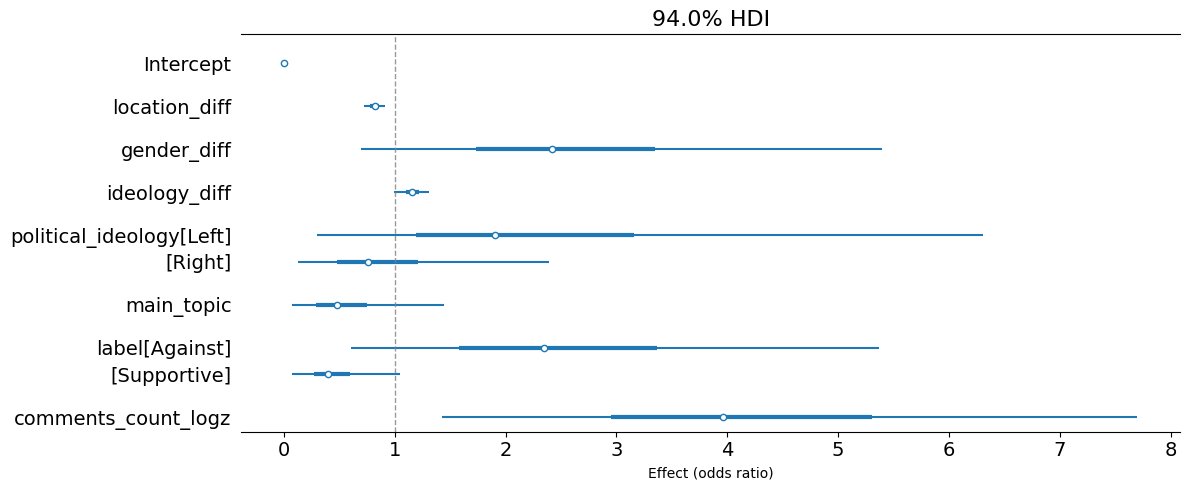

In [49]:
model = bmb.Model(
    "presence_no_rank ~ location_diff + gender_diff + ideology_diff + label + political_ideology + main_topic + comments_count_logz + (1|urlid) + (1|comment) + (1|setup_a) + (1|setup_b)",
    data=reg_df,
    family="bernoulli",
    dropna=True
)

results = model.fit(
    draws=800,      
    tune=800,       
    target_accept=0.95,
    chains=2,
    cores=1,
    # random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'political_ideology', 'main_topic', 'label', 'comments_count_logz']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-3.456,0.407,-4.209,-2.690,0.008,0.007,2328.0,2911.0,1.0
location[texas_texas],0.112,0.057,0.005,0.217,0.001,0.001,7703.0,5908.0,1.0
location[ny_texas],0.022,0.054,-0.085,0.118,0.001,0.001,7365.0,6153.0,1.0
gender[male_male],0.639,0.066,0.513,0.763,0.001,0.001,7075.0,5811.0,1.0
gender[female_male],0.966,0.061,0.844,1.077,0.001,0.001,6819.0,6021.0,1.0
...,...,...,...,...,...,...,...,...,...
1|urlid[DRYeCC9DP9C],-2.803,0.893,-4.473,-1.186,0.012,0.011,6274.0,4955.0,1.0
1|urlid[DRYfrKnDJXa],0.896,0.387,0.189,1.639,0.007,0.005,2756.0,4114.0,1.0
1|urlid[DRYg5_ZlC-O],-0.558,0.425,-1.343,0.262,0.008,0.005,2791.0,3842.0,1.0
1|urlid[DRYi49Elhfc],-2.426,0.944,-4.185,-0.679,0.012,0.012,6748.0,5031.0,1.0


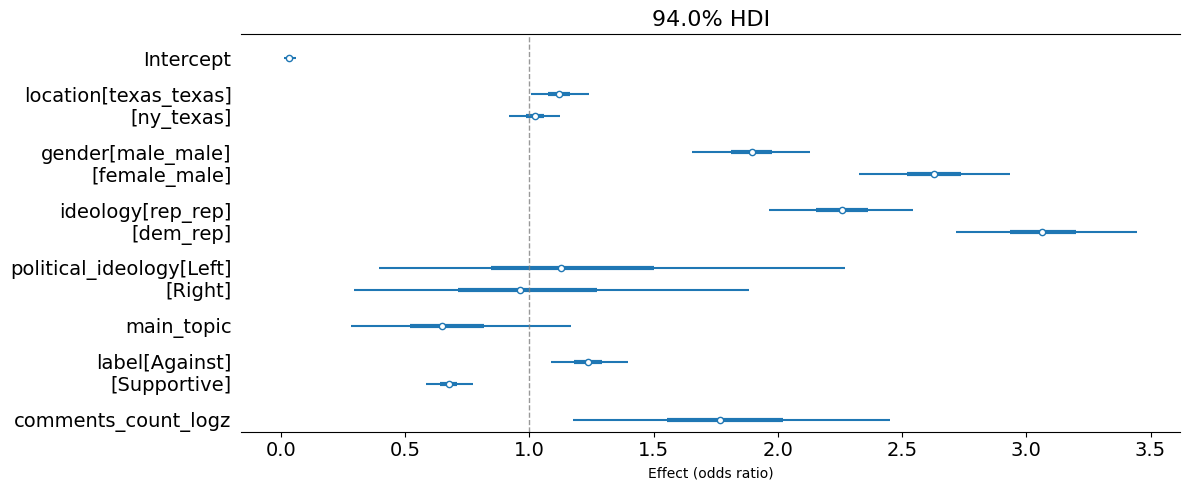

In [55]:
# model = bmb.Model(
#     "presence_no_rank ~ location + gender + ideology + label + political_ideology + main_topic + comments_count_logz + (1|urlid)",
#     data=reg_df,
#     family="bernoulli",
#     dropna=True
# )

# results = model.fit(
#     draws=2000,      
#     tune=2000,       
#     target_accept=0.95,
#     chains=4,
#     cores=1,
#     # random_seed=42,
# )
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location', 'gender', 'ideology', 'political_ideology', 'main_topic', 'label', 'comments_count_logz']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

In [58]:
reg_df[['location', 'ideology', 'gender', 'presence_no_rank']].value_counts()

location     ideology  gender         presence_no_rank
ny_texas     dem_rep   female_male    Yes                 827
ny_ny        dem_rep   female_male    Yes                 817
texas_texas  dem_rep   female_male    Yes                 812
ny_texas     dem_dem   female_male    Yes                 811
                       female_female  Yes                 803
             rep_rep   female_female  Yes                 799
texas_texas  dem_dem   female_male    Yes                 780
ny_texas     dem_rep   female_female  Yes                 779
             dem_dem   male_male      Yes                 770
             dem_rep   male_male      Yes                 769
ny_ny        dem_rep   female_female  Yes                 760
             dem_dem   female_male    Yes                 760
texas_texas  dem_rep   female_female  Yes                 758
ny_texas     rep_rep   male_male      Yes                 758
                       female_male    Yes                 750
ny_ny        re

In [79]:
reg_df[reg_df['presence_no_rank'] == 'No']['urlid'].value_counts()

urlid
DRXBM5Ojq4P    191
DRYGzcyEsGL    139
DRX71AeCgTh    126
DRXD15DkpPm    103
DRXeikNDutF    100
              ... 
DRVAqK1AYIk     14
DRYRxGYAUPl     14
DRYTefyEV_e     14
DRYdxYRDMFJ     13
DRNeXQakhum      9
Name: count, Length: 69, dtype: int64

In [80]:
news_df[news_df['urlid'] == 'DRYGzcyEsGL']

,account,urlid,caption,comment_num,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,...,chronological_comment,caption_text,male_dem_ny_1_comment_label,male_dem_texas_1_comment_label,male_rep_ny_1_comment_label,male_rep_texas_1_comment_label,female_dem_ny_1_comment_label,female_dem_texas_1_comment_label,female_rep_ny_1_comment_label,female_rep_texas_1_comment_label
867,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,0,NaN,"('neezey68', 'Wow, MSM was there. Good on you ...","('neezey68', 'Wow, MSM was there. Good on you ...",NaN,"('neezey68', 'Wow, MSM was there. Good on you ...","('neezey68', 'Wow, MSM was there. Good on you ...",...,"('joadeyestar', 'Do it')","Protesters gathered in Washington, D.C., for t...",None,Supportive,Supportive,None,Supportive,Supportive,Supportive,Supportive
868,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,1,NaN,"('jilldoyle77', 'WAS THERE! AWESOME ENERGY AND...","('jilldoyle77', 'WAS THERE! AWESOME ENERGY AND...",NaN,"('jilldoyle77', 'WAS THERE! AWESOME ENERGY AND...","('jilldoyle77', 'WAS THERE! AWESOME ENERGY AND...",...,"('brooklynbornstar2025', 'REMOVE HIM FROM OFFI...","Protesters gathered in Washington, D.C., for t...",None,Supportive,Supportive,None,Supportive,Supportive,Supportive,Supportive
869,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,2,NaN,"('_soul_of_mischief_', 'Taking America back, o...","('_soul_of_mischief_', 'Taking America back, o...",NaN,"('_soul_of_mischief_', 'Taking America back, o...","('_soul_of_mischief_', 'Taking America back, o...",...,"('flare.usa', ""Yeah!! Come see us in front of ...","Protesters gathered in Washington, D.C., for t...",None,Supportive,Supportive,None,Supportive,Supportive,Supportive,Supportive
870,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,3,NaN,"('titawalikitovenaar', '👏👏👏👏👏👏👏👏👏👏👏👏We stand w...","('saprofessor_cj', 'Impeach…Convict and remove...",NaN,"('titawalikitovenaar', '👏👏👏👏👏👏👏👏👏👏👏👏We stand w...","('titawalikitovenaar', '👏👏👏👏👏👏👏👏👏👏👏👏We stand w...",...,"('titawalikitovenaar', '👏👏👏👏👏👏👏👏👏👏👏👏We stand w...","Protesters gathered in Washington, D.C., for t...",None,Supportive,Supportive,None,Supportive,Supportive,Supportive,Supportive
871,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,4,NaN,"('saprofessor_cj', 'Impeach…Convict and remove...","('brestroup', 'Trump must be removed from offi...",NaN,"('saprofessor_cj', 'Impeach…Convict and remove...","('saprofessor_cj', 'Impeach…Convict and remove...",...,"('evolutionofzee', 'I hope the GOP in Congress...","Protesters gathered in Washington, D.C., for t...",None,Supportive,Supportive,None,Supportive,Supportive,Supportive,Supportive
872,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,5,NaN,"('brestroup', 'Trump must be removed from offi...","('titawalikitovenaar', '👏👏👏👏👏👏👏👏👏👏👏👏We stand w...",NaN,"('brestroup', 'Trump must be removed from offi...","('brestroup', 'Trump must be removed from offi...",...,"('neezey68', 'Wow, MSM was there. Good on you ...","Protesters gathered in Washington, D.C., for t...",None,Supportive,Supportive,None,Supportive,Supportive,Supportive,Supportive
873,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,6,NaN,"('evolutionofzee', 'I hope the GOP in Congress...","('rksenegal', 'Impeach, Convict and Remove!')",NaN,"('kalubifak', 'Nuremberg, part two awaits!\nHe...","('evolutionofzee', 'I hope the GOP in Congress...",...,"('rksenegal', 'Impeach, Convict and Remove!')","Protesters gathered in Washington, D.C., for t...",None,Supportive,Supportive,None,Against,Supportive,Against,Against
874,msnbc,DRYGzcyEsGL,msnownews\n 1 d\nProtesters gathered in Washin...,7,NaN,"('kalubifak', 'Nuremberg, part two awaits!\nHe...","('evolutionofzee', 'I hope the GOP in Congress...",NaN,"('evolutionofzee', 'I hope the GOP in Congress...","('kalubifak', 'Nuremb

In [18]:
labels_df1 = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='gpt annotations no account')
labels_df2 = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='annotations ideology')

In [19]:
labels_df1.shape, labels_df2.shape

((1013, 4), (980, 4))

In [20]:
labels_df1.columns, labels_df2.columns

(Index(['username', 'caption', 'comment', 'label'], dtype='object'),
 Index(['username', 'caption', 'comment', 'label'], dtype='object'))

In [21]:
merged_df = pd.merge(labels_df1, labels_df2, on=['username', 'caption', 'comment'], how='outer')

In [25]:
labels_df1['label'].value_counts()

label
Supportive    414
Against       389
Neutral       210
Name: count, dtype: int64

In [24]:
labels_df2['label'].value_counts()

label
Neutral                    673
Right leaning              160
Left leaning               146
Label: **Left leaning**      1
Name: count, dtype: int64

In [23]:
merged_df[['label_x', 'label_y']].value_counts()

label_x     label_y                
Supportive  Neutral                    290
Neutral     Neutral                    204
Against     Neutral                    202
            Left leaning                99
            Right leaning               87
Supportive  Right leaning               73
            Left leaning                51
Neutral     Right leaning                4
Against     Label: **Left leaning**      1
Neutral     Left leaning                 1
Name: count, dtype: int64

In [27]:
merged_df

NameError: name 'merged_df' is not defined

### other prompts

In [43]:
# labels_df = pd.DataFrame(columns=['account', 'caption', 'comment', 'label'])
# for account, caption, comment in zip(comments_df['account'], comments_df['caption'], comments_df['chronological_comment']):
#     prompt = f"""
#     You are a researcher annotating Instagram posts from news outlets.
#     Given the caption of an Instagram post and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
#     Label the comment as one of the following categories:
#     - Supportive: The comment expresses agreement, approval, or positive sentiment towards the content of the caption.
#     - Against: The comment expresses disagreement, disapproval, or negative sentiment towards the content of the caption.
#     - Neutral: The comment neither supports nor opposes the content of the caption; it may be factual or unrelated in tone.

#     Caption: "{caption}"
#     Account: "{account}"
#     Comment: "{comment}"

#     Label:
#     """

#     response = client.chat.completions.create(
#         model="gpt-5.2",
#         messages=[{"role": "user", "content": prompt}],
#         temperature=0
#     )

#     label = response.choices[0].message.content.strip()

#     labels_df = pd.concat([labels_df, pd.DataFrame({'account': [account], 'caption': [caption], 'comment': [comment], 'label': [label]})], ignore_index=True)

In [49]:
# labels_df = pd.DataFrame(columns=['account', 'caption', 'comment', 'label'])
# for account, caption, comment in zip(comments_df['account'], comments_df['caption'], comments_df['chronological_comment']):
#     prompt = f"""
#     You are a researcher annotating Instagram posts from news outlets.
#     Given the caption of an Instagram post and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
#     Label the comment as one of the following categories:
#     - Left leaning
#     - Right leaning
#     - Neutral

#     Caption: "{caption}"
#     Comment: "{comment}"

#     Label:
#     """

#     response = client.chat.completions.create(
#         model="gpt-5.2",
#         messages=[{"role": "user", "content": prompt}],
#         temperature=0
#     )

#     label = response.choices[0].message.content.strip()

#     labels_df = pd.concat([labels_df, pd.DataFrame({'account': [account], 'caption': [caption], 'comment': [comment], 'label': [label]})], ignore_index=True)

In [52]:
# labels_df = pd.DataFrame(columns=['account', 'caption', 'comment', 'label'])
# for account, caption, comment in zip(comments_df['account'], comments_df['caption'], comments_df['chronological_comment']):
#     prompt = f"""
#     You are a researcher annotating Instagram posts from news outlets.
#     Given the caption of an Instagram post, the news outlet where it was posted and a comment on that post, you are trying to determine the stance of the commenter with respect to the caption.
#     Label the comment as one of the following categories:
#     - Left leaning
#     - Right leaning
#     - Neutral

#     Caption: "{caption}"
#     Account: "{account}"
#     Comment: "{comment}"

#     Label:
#     """

#     response = client.chat.completions.create(
#         model="gpt-5.2",
#         messages=[{"role": "user", "content": prompt}],
#         # temperature=0
#     )

#     label = response.choices[0].message.content.strip()

#     labels_df = pd.concat([labels_df, pd.DataFrame({'account': [account], 'caption': [caption], 'comment': [comment], 'label': [label]})], ignore_index=True)